### **FX Trading Strategy Analysis**

The University of Chicago Project Lab: **Bank of America**

Author: Arjun Patel

Description: This notebook was created as part of the UChicago Summer 2026 project lab for members of Bank of America. It includes some exploratory findings regarding FX carry/momentum implementations and potential strategy suggestions. This notebook also serves as a space where I share some findings that I find insightful or helpful for strategy-building in the coming weeks. Additional analysis done on the various fx currencies can be found at https://github.com/theoyuanlee/FX_Carry_26_Summer_PL.git. This notebook serves as a summary so far, as well as some introduction to potential new areas of focus for the upcoming weeks.

---

### **Ⅰ. Universe** 

- We will utilize foreign exchange data pulled from a Bloomberg Terminal, specifically for G-10 currencies, Emerging Market (EM) currencies, and other macro variables that we could use as a proxy
    - We have data for G-10/EM rates, options, and spot/forward prices


In [1]:
# load data from utils
from arjun_utils import load_panels, PATHS, G10, EM, ALL_CCY
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

panels = load_panels()
spots, carry, xret, sret = panels.spots, panels.carry, panels.xret, panels.sret

panels.overview()          

FX carry panel  ·  1M forward-implied carry
────────────────────────────────────────────────────
  Universe    27 currencies   (9 G10, 18 EM)
  Sample      2007-01-01  →  2026-06-30   (19.5y, 5,094 obs)
  Panels      spots · carry · xret · sret
  Excluded    DKK, HKD  (pegs, not standard G10)
────────────────────────────────────────────────────
  .overview()  for the per-currency data card


,bucket,start,end,coverage_%
ccy,,,,
TRY,EM,2007-01-04,2026-06-30,99.500
ZAR,EM,2007-01-02,2026-06-30,99.500
SGD,EM,2007-01-02,2026-06-30,99.400
PLN,EM,2007-01-03,2026-06-30,99.300
MXN,EM,2007-01-03,2026-06-30,99.000
ILS,EM,2007-01-03,2026-06-30,98.700
HUF,EM,2007-01-02,2026-06-30,98.200
BRL,EM,2007-01-03,2026-06-30,92.400
THB,EM,2007-01-03,2026-06-30,91.900


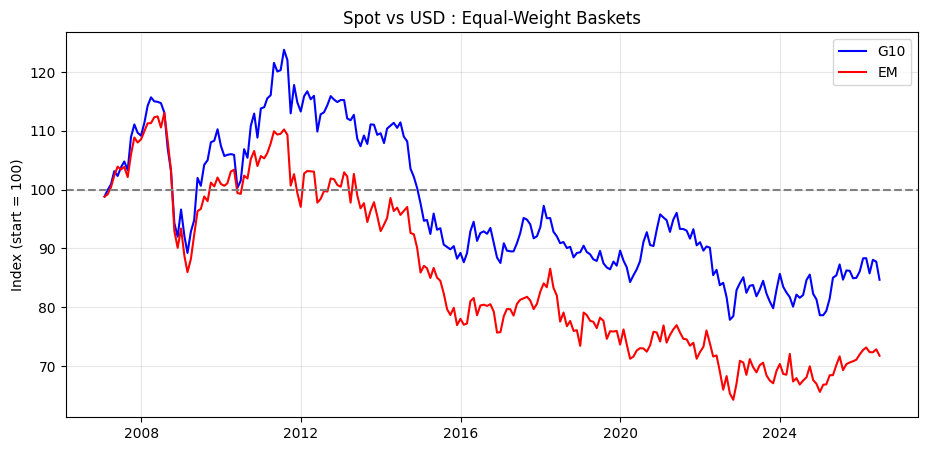

In [2]:
# Rebase basket to 100 for better visualization
def rebased_basket(spots, ccys):
    sub = spots[ccys].dropna(how="all")
    rebased = sub / sub.apply(lambda c: c.loc[c.first_valid_index()]) * 100
    return rebased.mean(axis=1)

g10_idx = rebased_basket(spots, panels.g10).resample("ME").last()
em_idx  = rebased_basket(spots, panels.em).resample("ME").last()

plt.figure(figsize=(11, 5))
plt.plot(g10_idx, label="G10", color="blue")
plt.plot(em_idx, label="EM", color="red")
plt.axhline(100, color="gray", linestyle="--")
plt.title("Spot vs USD : Equal-Weight Baskets")
plt.ylabel("Index (start = 100)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- Both G-10 and EM both rise from **2007 to mid 2008**. Around this time, the Fed was cutting rates as US housing cracked, while the rest of the world still had higher rates and booming commodity demand (currencies linked to commodites). A weak dollar caused capital to flow from USD to other currencies, casuing both baskets to go up

- **Later in 2008**, Lehman brothers and the financial crisis caused people who purchased other currencies (non USD) to buy back those dollars. The dollar acts as a safe-haven, and other fundamental non-USD currencies also take a hit, and both baskets sharply decline from this

- **2009 to 2011**, the Fed dropped rates to zero and launched QE, flooding the world with dollars and pushing investors back into higher-yielding currencies. The dollar weakened broadly and both baskets recovered, with G-10 running ahead of EM as commodity currencies rode China's post-crisis stimulus boom

- **2012 to 2014**, both baskets drift, but EM rolls over first. The 2013 taper tantrum, when the Fed hinted it would slow QE, hit high-yielding EM currencies hardest as years of yield-chasing inflows reversed. G-10 held up better since it was less dependent on those flows

- **2014 to 2015**, both baskets fall off a cliff. The Fed ended QE and signaled hikes while Europe and Japan eased further, swinging rate differentials toward the dollar. Oil and commodities collapsed at the same time, hammering commodity exporters. This is the decisive break that puts both baskets below 100 for good, with EM dropping much harder

- **2015 to 2020**, EM keeps grinding down while G-10 stabilizes around 90. Persistent dollar strength, weak commodities, and trade tensions kept punishing EM, which couldn't catch a bid, while G-10 chopped sideways. The gap between the two baskets widens into a persistent spread

- **2020 to 2022**, a brief COVID dollar spike hits both baskets, then EM falls to new lows near 65. The 2022 Fed hiking cycle, the fastest in decades, drove the dollar to multi-decade highs and pulled capital away from EM, which hit its worst levels of the whole period here

- **2023 to 2026**, both baskets stabilize and tick up as the hiking cycle peaks and the dollar softens. EM comes off its lows but stays deeply underwater versus where it started, more than a decade of net depreciation against the dollar that never reversed

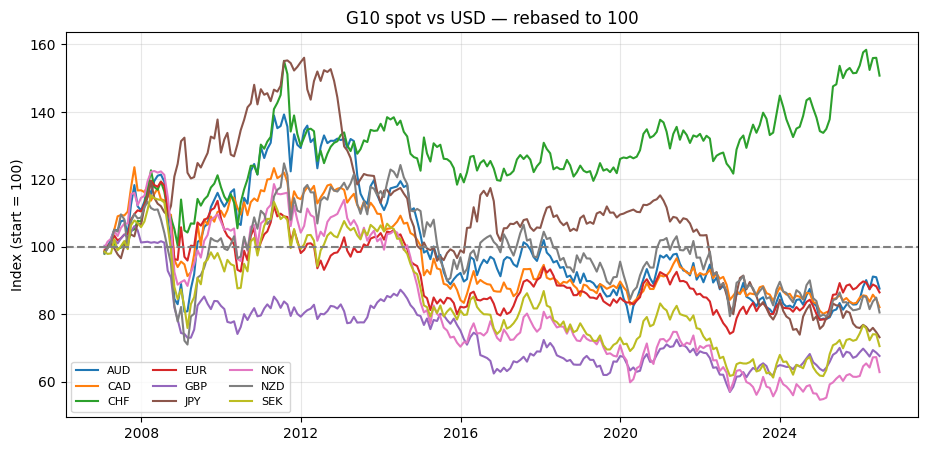

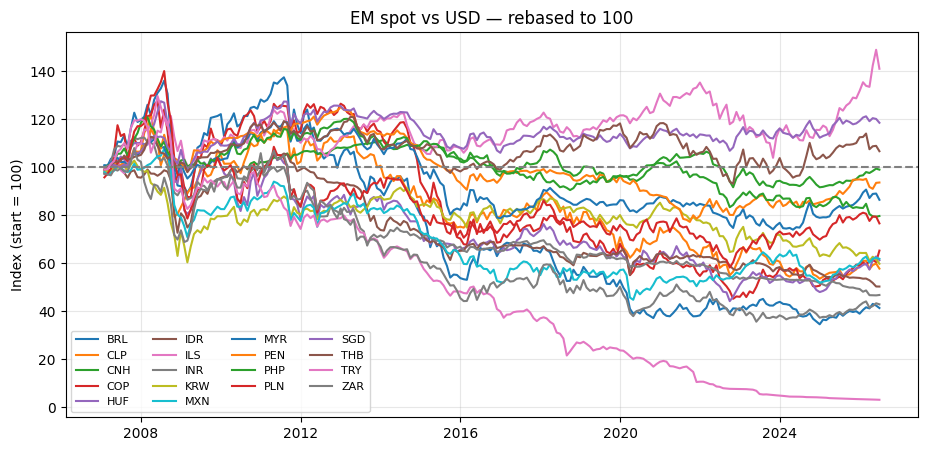

In [3]:
def rebased(spots, ccys):
    sub = spots[ccys].dropna(how="all")
    return sub / sub.apply(lambda c: c.loc[c.first_valid_index()]) * 100

g10_r = rebased(spots, panels.g10).resample("ME").last()
em_r  = rebased(spots, panels.em).resample("ME").last()

# G10
plt.figure(figsize=(11, 5))
for c in g10_r.columns:
    plt.plot(g10_r[c], label=c)
plt.axhline(100, color="gray", linestyle="--")
plt.title("G10 spot vs USD — rebased to 100")
plt.ylabel("Index (start = 100)")
plt.legend(ncol=3, fontsize=8)
plt.grid(alpha=0.3)
plt.show()

# EM
plt.figure(figsize=(11, 5))
for c in em_r.columns:
    plt.plot(em_r[c], label=c)
plt.axhline(100, color="gray", linestyle="--")
plt.title("EM spot vs USD — rebased to 100")
plt.ylabel("Index (start = 100)")
plt.legend(ncol=4, fontsize=8)
plt.grid(alpha=0.3)
plt.show()

### **Ⅱ. The Idea (Simple Strategy Execution)**

- **Carry**: The carry trade bets on the interest rate differential between two currencies. You borrow in a low-yielding currency and hold a high-yielding one, earning the difference as long as the exchange rate doesn't move against you. Under covered interest parity the forward already prices in this differential, so the carry is the annualised gap between spot and forward. The return you earn just by holding the currency forward. UIP says this should be offset by depreciation. The carry trade is the bet that it isn't, and historically it hasn't been fully offset, which is where the premium comes from.

- **Momentum**: Momentum bets that recent performance persists, currencies that have appreciated over some lookback window tend to keep appreciating over the near term, and vice versa. Instead of a rate differential, the signal is the currency's own past return: go long the recent winners and short the recent losers. It's a trend-following bet, and it tends to pay off in different environments than carry, which is why the two are often combined.

To demonstrate, we implement a simple **carry** strategy on **JPY/USD**, the classic funding-vs-target pair, where the yen's persistently low rates make it the textbook funding currency. We also observe a simple **momentum** strategy on **JPY** , using a trailing return signal on our spot data.

JPY/USD simple carry — sign(carry), daily rebalance
------------------------------------------------
Ann. return %        3.600
Ann. vol %           9.850
Sharpe               0.370
Max drawdown %     -36.800
Hit rate %          52.470
N days           5,079.000


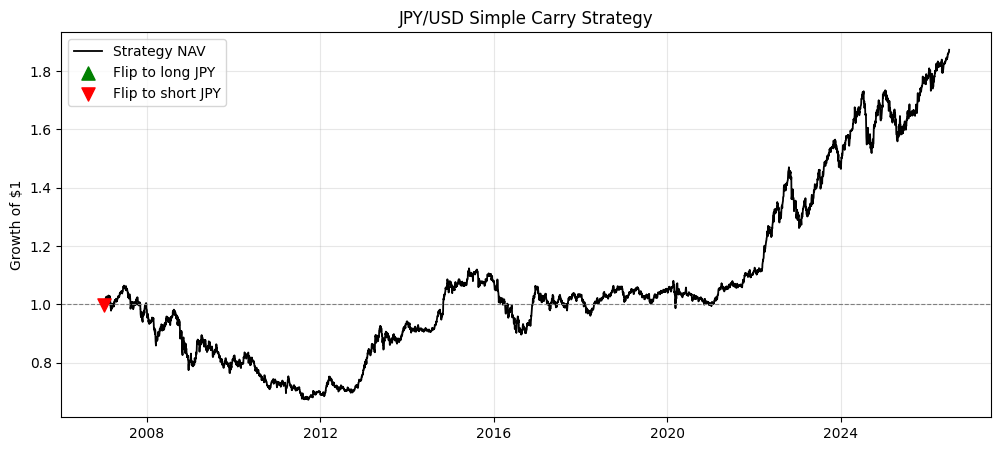

In [11]:
import numpy as np
import pandas as pd

# Signal & strategy returns
ccy = "JPY"

sig = np.sign(carry[ccy]).shift(1)      # long if carry>0, short if <0; lag 1d to avoid lookahead
strat_ret = sig * xret[ccy]             # position × next-day excess return
strat_ret = strat_ret.dropna()
sig = sig.reindex(strat_ret.index)

# Backtest metrics
ANN = 252
def metrics(r):
    ann_ret = r.mean() * ANN
    ann_vol = r.std() * np.sqrt(ANN)
    sharpe  = ann_ret / ann_vol if ann_vol else np.nan
    nav     = (1 + r).cumprod()
    maxdd   = (nav / nav.cummax() - 1).min()
    hit     = (r > 0).mean()
    return pd.Series({
        "Ann. return %": 100 * ann_ret,
        "Ann. vol %":    100 * ann_vol,
        "Sharpe":        sharpe,
        "Max drawdown %":100 * maxdd,
        "Hit rate %":    100 * hit,
        "N days":        len(r),
    })

stats = metrics(strat_ret)
print(f"JPY/USD simple carry — sign(carry), daily rebalance\n{'-'*48}")
print(stats.round(2).to_string())

nav = (1 + strat_ret).cumprod()

# mark only where the position CHANGES, not every day
flips = sig[sig != sig.shift(1)].dropna()
longs  = flips[flips > 0]
shorts = flips[flips < 0]

plt.figure(figsize=(12, 5))
plt.plot(nav.index, nav, color="black", lw=1.3, label="Strategy NAV")
plt.scatter(longs.index,  nav.reindex(longs.index,  method="ffill"),
            marker="^", color="green", s=90, zorder=3, label="Flip to long JPY")
plt.scatter(shorts.index, nav.reindex(shorts.index, method="ffill"),
            marker="v", color="red",   s=90, zorder=3, label="Flip to short JPY")
plt.axhline(1, color="gray", linestyle="--", lw=0.8)
plt.title("JPY/USD Simple Carry Strategy")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

JPY/USD simple momentum — sign(12m return), daily rebalance
----------------------------------------------------
Ann. return %        3.760
Ann. vol %           9.860
Sharpe               0.380
Max drawdown %     -23.850
Hit rate %          52.430
N days           4,827.000


/var/folders/3m/9vs2kbw5395dntphy60zph4h0000gn/T/ipykernel_23004/1869415358.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  mom = spots[ccy].pct_change(LOOKBACK)      # trailing return: + = uptrend, - = downtrend


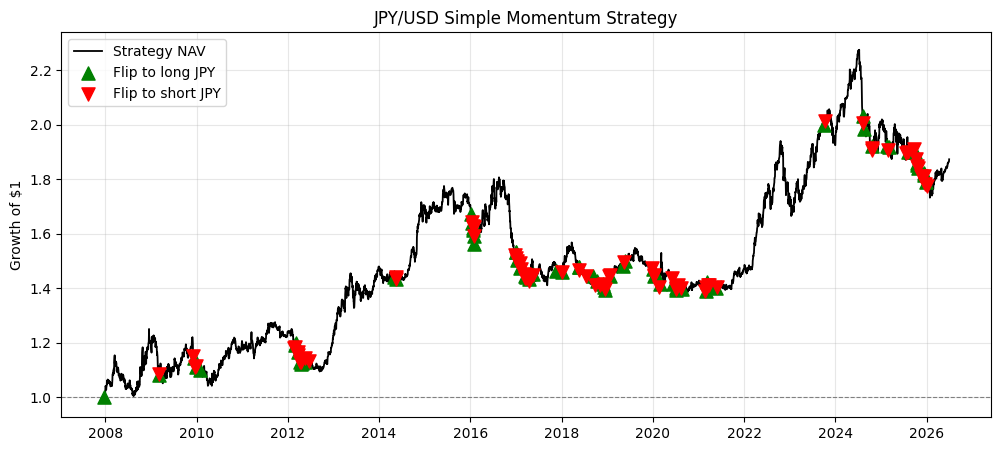

In [13]:
LOOKBACK = 252     # 12-month trailing return as the momentum signal

# Signal & strategy returns
mom = spots[ccy].pct_change(LOOKBACK)      # trailing return: + = uptrend, - = downtrend
sig = np.sign(mom).shift(1)                # long if trending up, short if down; lag 1d
strat_ret = (sig * xret[ccy]).dropna()
sig = sig.reindex(strat_ret.index)

# Backtest metrics (same function as carry
ANN = 252
def metrics(r):
    ann_ret = r.mean() * ANN
    ann_vol = r.std() * np.sqrt(ANN)
    sharpe  = ann_ret / ann_vol if ann_vol else np.nan
    nav     = (1 + r).cumprod()
    maxdd   = (nav / nav.cummax() - 1).min()
    hit     = (r > 0).mean()
    return pd.Series({
        "Ann. return %":  100 * ann_ret,
        "Ann. vol %":     100 * ann_vol,
        "Sharpe":         sharpe,
        "Max drawdown %": 100 * maxdd,
        "Hit rate %":     100 * hit,
        "N days":         len(r),
    })

print(f"JPY/USD simple momentum — sign(12m return), daily rebalance\n{'-'*52}")
print(metrics(strat_ret).round(2).to_string())

nav = (1 + strat_ret).cumprod()
flips  = sig[sig != sig.shift(1)].dropna()
longs  = flips[flips > 0]
shorts = flips[flips < 0]

plt.figure(figsize=(12, 5))
plt.plot(nav.index, nav, color="black", lw=1.3, label="Strategy NAV")
plt.scatter(longs.index,  nav.reindex(longs.index,  method="ffill"),
            marker="^", color="green", s=90, zorder=3, label="Flip to long JPY")
plt.scatter(shorts.index, nav.reindex(shorts.index, method="ffill"),
            marker="v", color="red",   s=90, zorder=3, label="Flip to short JPY")
plt.axhline(1, color="gray", linestyle="--", lw=0.8)
plt.title("JPY/USD Simple Momentum Strategy")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Simple Carry vs Momentum — JPY/USD

We demonstrate both signals on a single pair, JPY/USD, using our spot, forward, and rate data.

- **Carry** goes long the currency with the higher yield. Since JPY is a chronic low-yielder, the signal is short JPY ~99.8% of the time — the classic yen funding trade. It flips essentially once and holds. It bled from 2008–2012 as the yen rallied in the crisis (the carry trade's tail risk), then paid off strongly post-2022 as the BoJ held near zero while the Fed hiked. Sharpe **0.37**, max drawdown **−37%**.

- **Momentum** goes long when JPY's 12-month trailing return is positive, short when negative. It flips **142 times**, clustering into whipsaws when the trend is flat. Sharpe **0.38**, max drawdown **−24%**.

**Takeaway.** Gross of costs, momentum marginally edges carry with a shallower drawdown. But these backtests include **no transaction costs**, so don't trust the ranking blindly: carry trades roughly once, while momentum's 142 flips carry real turnover. Once costs are charged, carry's near-static positioning likely wins. 

### **Ⅲ. Building and Testing Portfolios**

- A single-currency trade like the JPY carry demo isn't a strategy it's one bet with one currency's idiosyncratic risk. The premium shows up only when you diversify across the cross-section. But before asking *how* to weight the book, we settle a prior question: **where does the premium actually come from, 10 or EM?**

- We build three books the same way — rank currencies by carry, go long the high-yield bucket and short the low-yield bucket, then scale each book to a common volatility target so they're comparable. The only difference is the universe: **G10-only**, **EM-only**, and **Combined**. Each is shown gross and net of transaction costs, and benchmarked against the Deutsche Bank G10 (DBHVG10U) and EM (FXCTEM8) carry indices.

The result is the whole thesis in one table: **G10-only carry is thin** (Sharpe ~0.17 gross, and the DB G10 index is actually negative), while **combining with EM roughly quadruples the risk-adjusted return** and clears the benchmark net of costs. The carry premium in this data is an EM story.

In [26]:
from pathlib import Path
OUTPUTS = Path("../cesare/outputs")

# Universes & vol target (pegs DKK/HKD and forward-less CNY excluded)
UNIVERSE_G10 = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]
UNIVERSE_ALL = [c for c in xret.columns if c not in ("HKD", "DKK", "CNY")]
UNIVERSE_EM  = [c for c in UNIVERSE_ALL if c not in UNIVERSE_G10]
VOL_TARGET   = 0.10
print(f"G10={len(UNIVERSE_G10)}  EM={len(UNIVERSE_EM)}  combined={len(UNIVERSE_ALL)}")

# Build each book: rank->bucket->vol-target->returns (gross & net)
hs_out, hs_pts = fx.forward_halfspreads(tenor="1M")

def build_book(universe, n_buckets, name="book"):
    w_unit = fx.carry_portfolio(carry, xret, n_buckets=n_buckets, universe=universe)
    w_vt   = fx.vol_target_weights(w_unit, xret, target=VOL_TARGET)
    gross  = fx.portfolio_returns(w_vt, xret, f"{name}_gross")
    net    = (gross - fx.roundtrip_cost(w_vt, hs_out, hs_pts)).rename(f"{name}_net")
    return gross, net, w_vt

g10_gross, g10_net, w_g10 = build_book(UNIVERSE_G10, 3, "G10")   # terciles
all_gross, all_net, w_all = build_book(UNIVERSE_ALL, 5, "ALL")   # quintiles
em_gross,  em_net,  w_em  = build_book(UNIVERSE_EM,  3, "EM")    # terciles
bmk = fx.benchmark_returns()

# Reconciliation gate: rebuilt numbers must match committed baseline ---
committed = pd.read_csv(OUTPUTS / "strategy_summary_stats.csv", index_col=0)
def sharpe(r):
    r = r.dropna(); return r.mean() * fx.ANN_DAYS / (r.std() * np.sqrt(fx.ANN_DAYS))
recon = pd.DataFrame({
    "G10_net": [sharpe(g10_net), committed.loc["G10_net", "sharpe"]],
    "ALL_net": [sharpe(all_net), committed.loc["ALL_net", "sharpe"]],
}, index=["rebuilt", "committed"]).T
recon["abs_diff"] = (recon["rebuilt"] - recon["committed"]).abs()
print(recon.round(4))

# Results table
tracks = pd.concat([g10_gross, g10_net, em_gross, em_net, all_gross, all_net], axis=1)
stats = fx.summary_stats(tracks)
cols = ["ann_return", "ann_vol", "sharpe", "sortino", "max_drawdown", "calmar", "skew", "hit_rate"]
stats[cols].round(3)

G10=9  EM=18  combined=27
         rebuilt  committed  abs_diff
G10_net    0.119      0.119     0.000
ALL_net    0.466      0.466     0.000


,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar,skew,hit_rate
G10_gross,0.019,0.115,0.167,0.222,-0.365,0.035,-0.954,0.531
G10_net,0.014,0.115,0.119,0.159,-0.382,0.019,-0.952,0.529
EM_gross,0.067,0.110,0.606,0.840,-0.356,0.176,-0.438,0.537
EM_net,0.042,0.111,0.376,0.517,-0.405,0.089,-0.431,0.529
ALL_gross,0.070,0.112,0.628,0.861,-0.268,0.247,-0.652,0.544
ALL_net,0.052,0.112,0.466,0.634,-0.293,0.160,-0.648,0.538


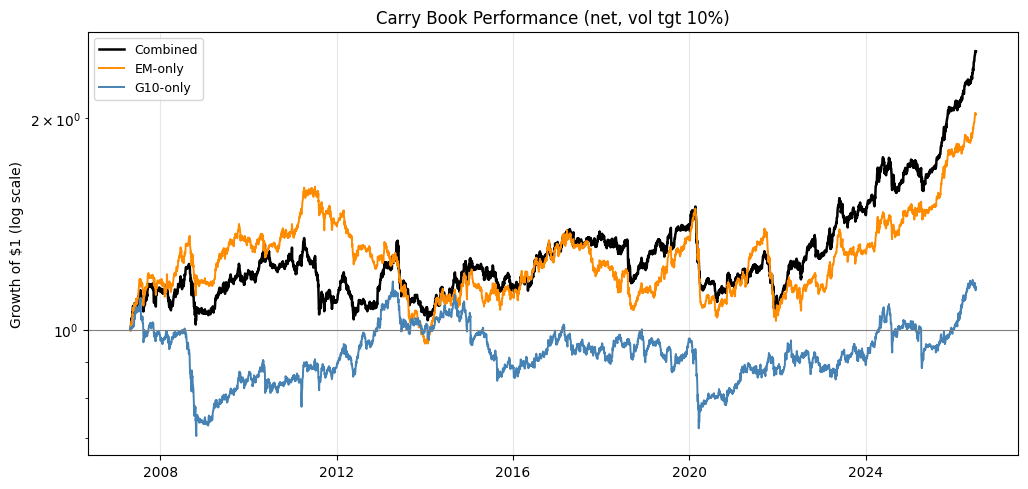

In [ ]:
tracks_net = pd.concat([g10_net, em_net, all_net], axis=1).dropna()
nav = (1 + tracks_net).cumprod()

plt.figure(figsize=(12, 5.5))
plt.plot(nav.index, nav["ALL_net"], label="Combined", color="black", lw=1.8)
plt.plot(nav.index, nav["EM_net"],  label="EM-only",  color="darkorange", lw=1.4)
plt.plot(nav.index, nav["G10_net"], label="G10-only", color="steelblue", lw=1.4)
plt.axhline(1, color="gray", lw=0.8)
plt.yscale("log")                      # tames the recent surge, shows early years fairly
plt.title("Carry Book Performance (net, vol tgt 10%)")
plt.ylabel("Growth of $1 (log scale)")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

- Combining G-10 and EM yields the best performance, and with trading costs included, yields the highest sharpe ratio.

**Where is the premium coming from?**

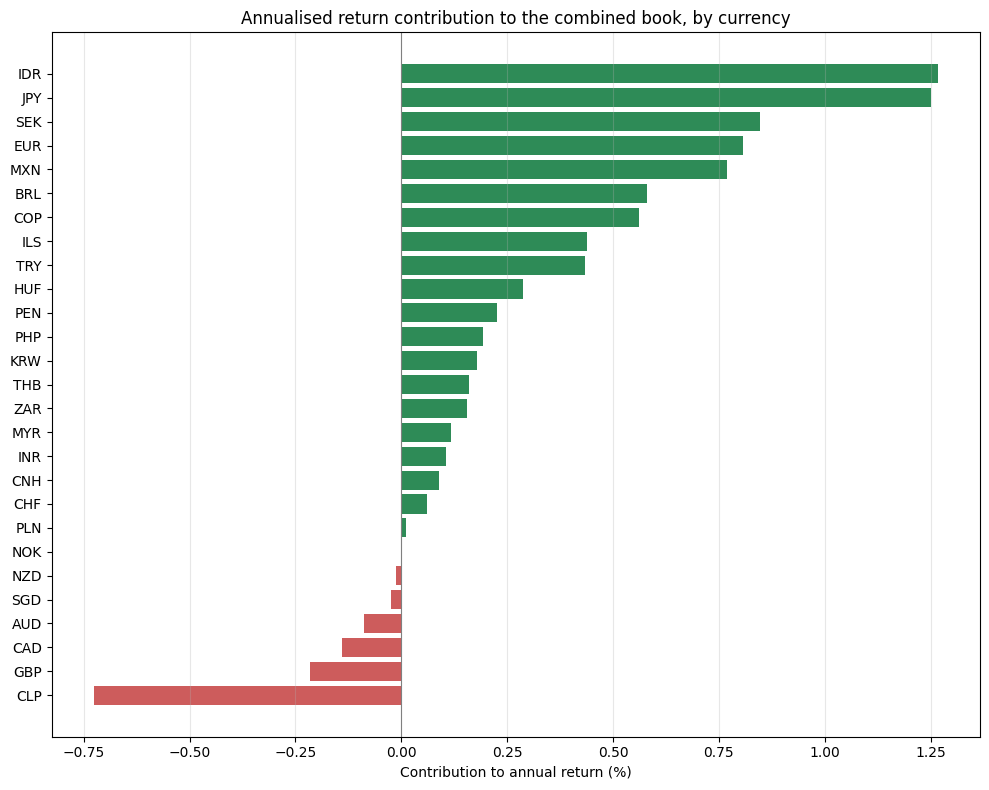

In [31]:
WIN0, WIN1 = all_net.dropna().index[[0, -1]]
# per-currency contribution to the combined book: w_all * xret, summed over the window
common_cols = w_all.columns.intersection(xret.columns)
contrib = (w_all[common_cols] * xret[common_cols]).loc[WIN0:WIN1]

# annualised mean contribution per currency (daily mean × 252), in %
ann_contrib = (contrib.mean() * fx.ANN_DAYS * 100).sort_values()

# color by sign: positive = green, negative = red
colors = ["seagreen" if v >= 0 else "indianred" for v in ann_contrib]

plt.figure(figsize=(10, 8))
plt.barh(ann_contrib.index, ann_contrib.values, color=colors)
plt.axvline(0, color="gray", lw=0.8)
plt.title("Annualised return contribution to the combined book, by currency")
plt.xlabel("Contribution to annual return (%)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**Is our result reliable and robust?**

In [34]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

CESARE = Path("../cesare").resolve()
sys.path.insert(0, str(CESARE))
import fx_utils as fx

OUTPUTS = CESARE / "outputs"

# --- panel chain ---
g10_px = fx.load_wide("g10_fx_spot_forward")
em_px  = fx.load_wide("em_fx_spot_forward")
spots  = fx.spots_usd_per_fx(g10_px, em_px)
carry  = fx.carry_panel(g10_px, em_px, tenor="1M")
xret   = fx.excess_returns(spots, carry)

UNIVERSE_G10 = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]
UNIVERSE_ALL = [c for c in xret.columns if c not in ("HKD", "DKK", "CNY")]
VOL_TARGET = 0.10

# --- book builder (one knob per robustness variant) ---
hs_out, hs_pts = fx.forward_halfspreads(tenor="1M")

def build_book(universe, n_buckets, target=VOL_TARGET, vol_window=60, rebal="ME",
               max_leg_share=0.40, weighting="inv_vol", cov_window=250, name="book"):
    w_unit = fx.carry_portfolio(carry, xret, n_buckets=n_buckets, universe=universe,
                                vol_window=vol_window, rebal=rebal, max_leg_share=max_leg_share,
                                weighting=weighting, cov_window=cov_window)
    w_vt = fx.vol_target_weights(w_unit, xret, target=target, window=vol_window, rebal=rebal)
    gross = fx.portfolio_returns(w_vt, xret, f"{name}_gross")
    net = (gross - fx.roundtrip_cost(w_vt, hs_out, hs_pts)).rename(f"{name}_net")
    return gross, net, w_unit, w_vt

g10_gross, g10_net, w_g10_unit, w_g10 = build_book(UNIVERSE_G10, 3, name="G10")
all_gross, all_net, w_all_unit, w_all = build_book(UNIVERSE_ALL, 5, name="ALL")

# --- helpers + reconciliation gate ---
committed = pd.read_csv(OUTPUTS / "strategy_summary_stats.csv", index_col=0)

def sharpe(r):
    r = r.dropna()
    return r.mean() * fx.ANN_DAYS / (r.std() * np.sqrt(fx.ANN_DAYS))

WIN0, WIN1 = all_net.dropna().index[[0, -1]]
def win(s): return s.loc[WIN0:WIN1]

def rolling_sharpe(r, window_days=756, min_periods=504):
    r = win(r)
    mu = r.rolling(window_days, min_periods=min_periods).mean() * fx.ANN_DAYS
    sd = r.rolling(window_days, min_periods=min_periods).std() * np.sqrt(fx.ANN_DAYS)
    return (mu / sd).rename(r.name)

assert abs(sharpe(all_net) - committed.loc["ALL_net", "sharpe"]) < 5e-3, "Reconciliation FAILED"
print("Setup complete, reconciliation PASSED. Combined net Sharpe:", round(sharpe(all_net), 3))

Setup complete, reconciliation PASSED. Combined net Sharpe: 0.466


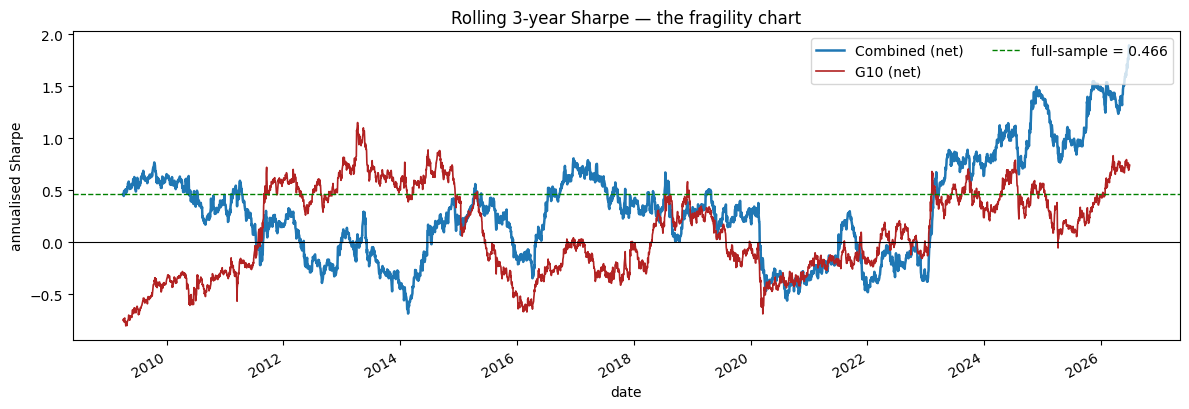

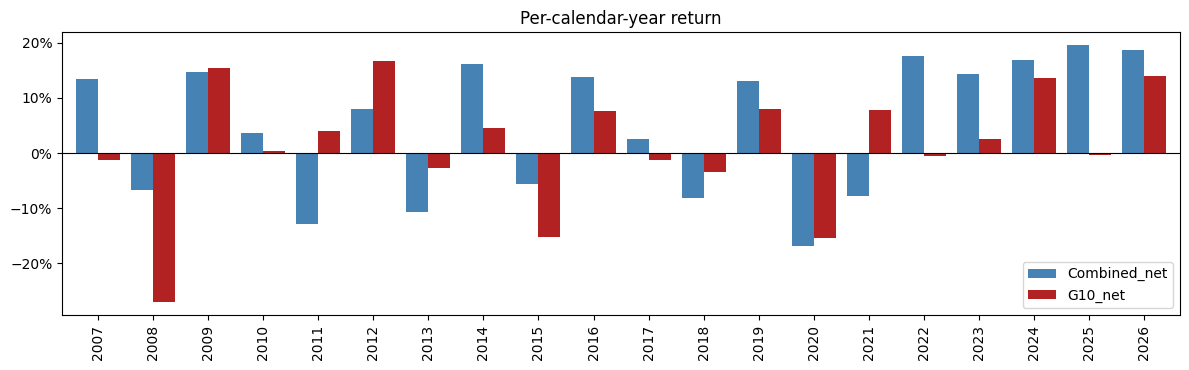

In [35]:
fig, ax = plt.subplots(figsize=(12, 4.2))
rolling_sharpe(all_net).plot(ax=ax, label="Combined (net)", lw=1.8)
rolling_sharpe(g10_net).plot(ax=ax, label="G10 (net)", lw=1.2, color="firebrick")
ax.axhline(0, color="k", lw=0.8)
ax.axhline(committed.loc["ALL_net", "sharpe"], color="green", ls="--", lw=1, label="full-sample = 0.466")
ax.set_title("Rolling 3-year Sharpe — the fragility chart")
ax.set_ylabel("annualised Sharpe"); ax.legend(loc="upper right", ncol=2)
plt.tight_layout(); plt.show()

yr = pd.DataFrame({"Combined_net": win(all_net), "G10_net": win(g10_net)}).resample("YE").sum()
yr.index = yr.index.year
fig, ax = plt.subplots(figsize=(12, 3.8))
yr.plot.bar(ax=ax, width=0.8, color=["steelblue", "firebrick"])
ax.axhline(0, color="k", lw=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Per-calendar-year return"); ax.set_xlabel(None)
plt.tight_layout(); plt.show()

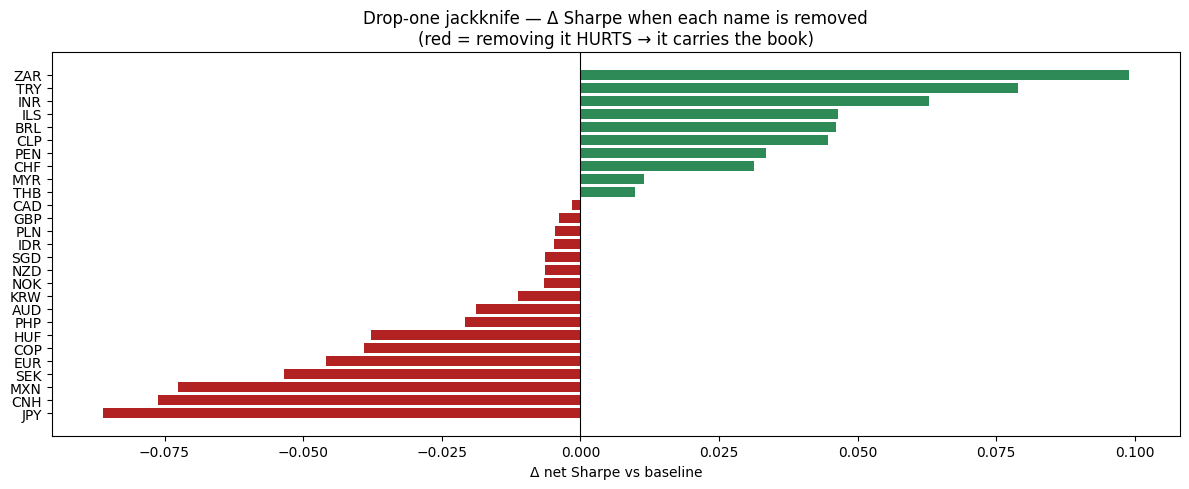

Cumulatively removing the most-carrying currencies:


,dropped_k,dropped,net_sharpe
0,0,(none),0.466
1,1,JPY,0.380
2,2,"JPY, CNH",0.364
3,3,"JPY, CNH, MXN",0.231
4,4,"JPY, CNH, MXN, SEK",0.235
5,5,"JPY, CNH, MXN, SEK, EUR",0.233


In [36]:
base = sharpe(win(all_net))
jack = {}
for ccy in UNIVERSE_ALL:
    u = [c for c in UNIVERSE_ALL if c != ccy]
    _, net_i, _, _ = build_book(u, 5, name=f"ex_{ccy}")
    jack[ccy] = sharpe(win(net_i))
jack_tbl = pd.Series(jack, name="sharpe_without").sort_values().to_frame()
jack_tbl["delta_vs_base"] = jack_tbl["sharpe_without"] - base

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["firebrick" if d < 0 else "seagreen" for d in jack_tbl["delta_vs_base"]]
ax.barh(jack_tbl.index, jack_tbl["delta_vs_base"], color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_title("Drop-one jackknife — Δ Sharpe when each name is removed\n"
             "(red = removing it HURTS → it carries the book)")
ax.set_xlabel("Δ net Sharpe vs baseline")
plt.tight_layout(); plt.show()

most_carrying = jack_tbl.sort_values("delta_vs_base").index.tolist()
rows = []
for k in range(0, 6):
    drop = most_carrying[:k]
    u = [c for c in UNIVERSE_ALL if c not in drop]
    _, net_i, _, _ = build_book(u, 5, name="tmp")
    rows.append({"dropped_k": k, "dropped": ", ".join(drop) or "(none)", "net_sharpe": sharpe(win(net_i))})
print("Cumulatively removing the most-carrying currencies:")
pd.DataFrame(rows).round(3)

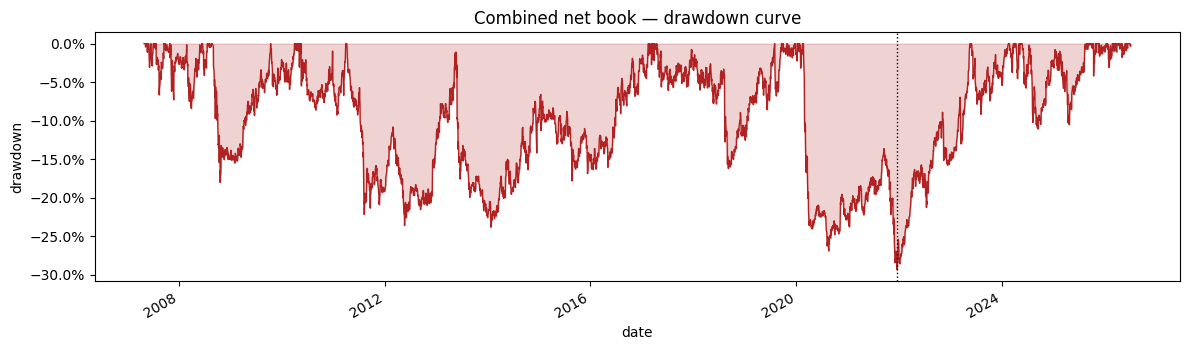

max drawdown:  -29.3%
peak → trough: 2020-02-19 → 2021-12-16
recovered:     2023-05-17  (~3.2y underwater)


In [39]:
def drawdown_curve(r):
    w = (1 + win(r).dropna()).cumprod()
    return w / w.cummax() - 1

dd = drawdown_curve(all_net)
trough = dd.idxmin()
w = (1 + win(all_net).dropna()).cumprod()
peak = w.loc[:trough].idxmax()
after = w.loc[trough:]
recov = after[after >= w.loc[peak]]
recov_date = recov.index[0] if len(recov) else None

fig, ax = plt.subplots(figsize=(12, 3.6))
dd.plot(ax=ax, color="firebrick", lw=1)
ax.fill_between(dd.index, dd.values, 0, color="firebrick", alpha=0.2)
ax.axvline(trough, color="k", ls=":", lw=1)
ax.set_title("Combined net book — drawdown curve"); ax.set_ylabel("drawdown")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); plt.tight_layout(); plt.show()

print(f"max drawdown:  {dd.min():.1%}")
print(f"peak → trough: {peak.date()} → {trough.date()}")
if recov_date is not None:
    print(f"recovered:     {recov_date.date()}  (~{(recov_date - peak).days/365.25:.1f}y underwater)")
else:
    print(f"underwater as of end: {(dd.index[-1] - peak).days/365.25:.1f} years and counting")

**Verdict: Real but fragile.** The 0.466 net Sharpe survives the audit as a *number*, but not as a *robust, reliable edge*. It is cyclical (a decade underwater, 2010–2020, then a recent surge), concentrated (a handful of names led by JPY, CNH, and MXN carry the book), parameter-sensitive (the baseline is an isolated peak, not a plateau), and cost-sensitive (the gross-to-net gap is already large, and the edge degrades steadily as spreads inflate). None of these individually invalidates the result, but together they say the same thing: this is a cyclical, concentrated bet that recent EM strength persists, not a structural premium you'd bank on out-of-sample.

### **Ⅳ. Hedging Carry with Derivatives**

The audit showed the book's core weakness: negative skew. Carry earns steadily, then gives a chunk back all at once when the dollar spikes (2008, 2020). The natural hedges are derivatives that pay off exactly in those episodes:

- **FX options (puts on high-yielders)**: Buying out-of-the-money puts on the currencies we are long converts the fat left tail into a known premium cost. The classic structure is a **risk reversal**, sell an OTM call on the currency, buy the OTM put, which directly offsets the crash exposure a long-carry position has.
- **Straddles / vol positions**: Carry loses money when volatility spikes. Being long vol (straddles on USD pairs, or VIX-style FX vol futures) is a rough macro hedge, since the carry unwind and the vol spike are the same event.
- **Forwards / futures on the dollar index (DXY)**: The book's losses cluster when the *dollar broadly* strengthens. A long-DXY futures overlay is the cheapest blunt hedge, no options premium, but it also dilutes the carry we're being paid.

**Data we have vs data we need:**

- We already have **1M option surfaces** (ATM vol, 25-delta risk reversals, butterflies) for all G-10 pairs and 13 EM currencies (missing: CLP, COP, IDR, MYR, PEN, PHP)
- To actually *price* a hedge program we would need: longer option tenors (3M/6M for cheaper rolls), **option bid/ask spreads** (hedge costs decide everything, same lesson as Section Ⅲ), and ideally historical prices for DXY futures as the cheap alternative.

The cell below shows the hedge signal is already sitting in our data: the risk reversal (crash-insurance price) per currency.

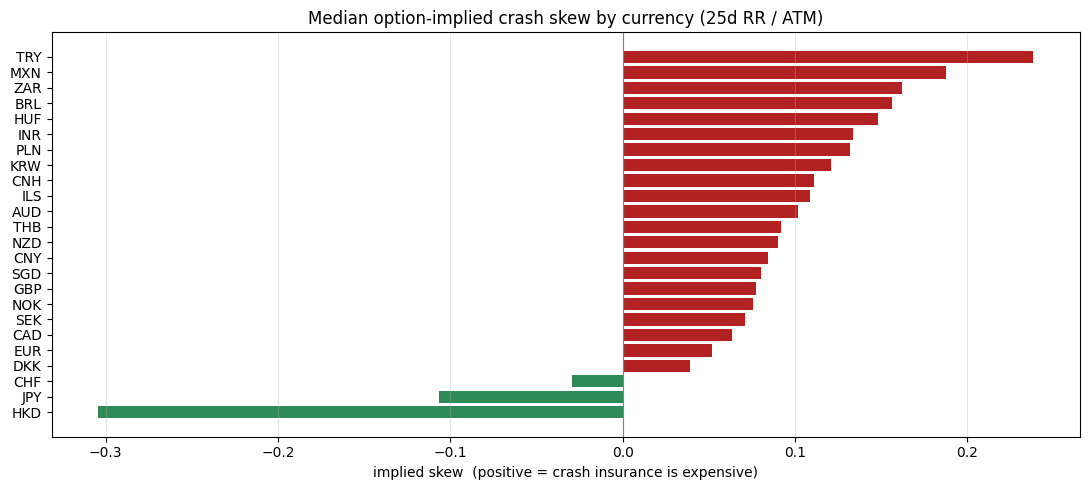

In [41]:
# option-implied crash skew (25d risk reversal / ATM vol), from our own options data
skew = fx.implied_skew_panel(tenor="1M")          # positive = market pricing a crash for long-FX
med_skew = skew.median().sort_values()

plt.figure(figsize=(11, 5))
colors = ["firebrick" if v > 0 else "seagreen" for v in med_skew]
plt.barh(med_skew.index, med_skew.values, color=colors)
plt.axvline(0, color="gray", lw=0.8)
plt.title("Median option-implied crash skew by currency (25d RR / ATM)")
plt.xlabel("implied skew  (positive = crash insurance is expensive)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

- Each bar is what the options market charges for crash protection on that currency. Almost everything is **red (positive)**: puts cost more than calls, meaning the market already prices the risk of these currencies falling hard, the same crash risk we found in the drawdown audit.
- The three green names make sense: **JPY and CHF are safe havens** (they *rise* in a crisis, so the market prices the opposite tail), and HKD is pegged to the dollar.
- Takeaway for hedging: we *can* buy protection, but it's priced. The currencies we most want to insure (TRY, MXN, ZAR, the high-carry names at the top) have the most expensive insurance. **Hedging carry means giving back a chunk of the carry.**

### **Ⅴ. What the Options Market Already Knows**

If the carry premium is compensation for crash risk, then the currencies paying the most carry should be the ones whose options price the most crash risk. We can test that directly with data we already have: average carry vs average implied skew, per currency.

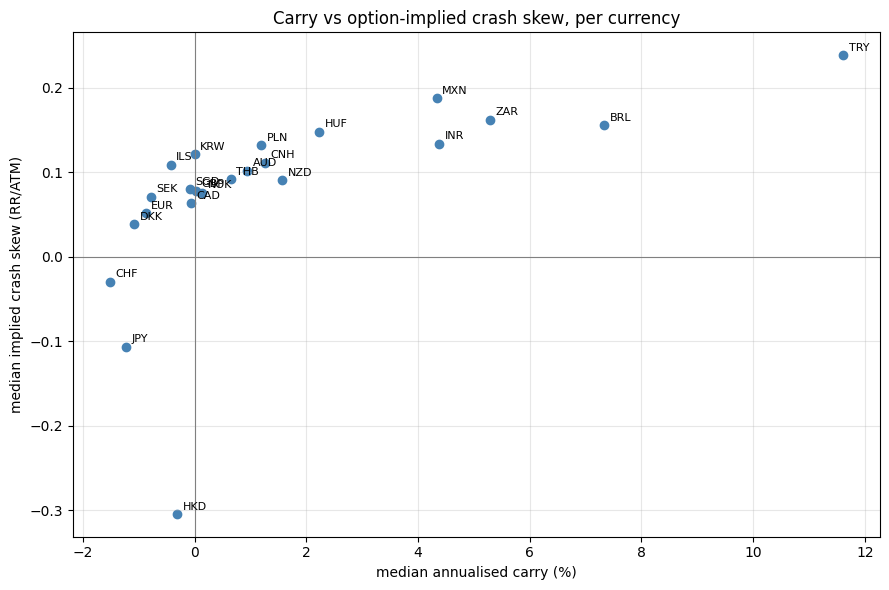

cross-sectional correlation (carry vs implied skew): 0.59


In [43]:
# cross-section: does higher carry come with more expensive crash insurance?
common = carry.columns.intersection(skew.columns)
avg_carry = carry[common].median() * 100          # in %
avg_skew  = skew[common].median()

plt.figure(figsize=(9, 6))
plt.scatter(avg_carry, avg_skew, color="steelblue")
for c in common:
    plt.annotate(c, (avg_carry[c], avg_skew[c]), fontsize=8,
                 xytext=(4, 3), textcoords="offset points")
plt.axhline(0, color="gray", lw=0.8); plt.axvline(0, color="gray", lw=0.8)
plt.xlabel("median annualised carry (%)")
plt.ylabel("median implied crash skew (RR/ATM)")
plt.title("Carry vs option-implied crash skew, per currency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr = avg_carry.corr(avg_skew)
print(f"cross-sectional correlation (carry vs implied skew): {corr:.2f}")

- Each dot is one currency: how much carry it pays (x-axis) vs how much the options market charges to insure against it crashing (y-axis). The pattern is clear: **the more carry a currency pays, the more expensive its crash insurance**. TRY pays the most carry and has the priciest insurance; JPY and CHF pay negative carry and their insurance is so unwanted the skew goes negative.
- This tells us the carry premium is not free money, it's **payment for crash risk the market already sees**. The same currencies that pay us carry are the ones the options market expects to fall hardest in a sell-off.
- One idea to test later: look for currencies with **high carry but unusually cheap insurance**, that's carry the options market isn't worried about. (Options data is missing for 6 EM names, including IDR, so this only works on the covered universe.)

### **Ⅵ. A Variant Worth Testing: Momentum-Filtered Carry**

Sections Ⅱ–Ⅲ showed carry and momentum are different bets that pay in different regimes. The engine supports combining them as a **double sort**: keep a long (high-carry) position only if the currency is also trending up, and a short (low-carry) only if it's trending down. The idea is to avoid the classic carry disaster, being long a high-yielder while it's actively crashing (the TRY problem: carry accrual wiped out by spot depreciation).

- This is a *filter*, not a new book: same carry ranking, same weighting, same costs, one extra condition.
- Honest prior: overlays tested so far on this book (hedges, regimes, skew) have not beaten plain carry **net of costs**, filters cut losses but also cut the carry you collect, and add turnover. So the bar is: does it beat 0.466 net?

Baseline carry vs momentum-filtered carry (both net of costs):


,ann_return,ann_vol,sharpe,max_drawdown,skew,hit_rate
ALL_net,0.052,0.112,0.466,-0.293,-0.648,0.538
FILT_net,0.043,0.116,0.373,-0.506,-0.658,0.531


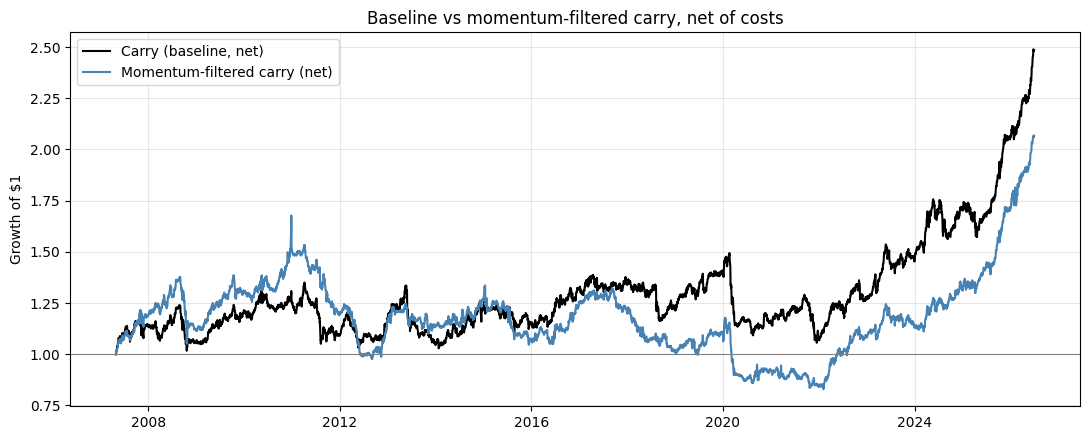

In [44]:
# momentum-filtered carry: double sort using the engine's built-in filter_signal
mom = fx.momentum_panel(xret, lookback=63)     # 3-month trailing excess return

w_filt_unit = fx.carry_portfolio(carry, xret, n_buckets=5, universe=UNIVERSE_ALL,
                                 filter_signal=mom)
w_filt = fx.vol_target_weights(w_filt_unit, xret, target=VOL_TARGET)
filt_gross = fx.portfolio_returns(w_filt, xret, "FILT_gross")
filt_net = (filt_gross - fx.roundtrip_cost(w_filt, hs_out, hs_pts)).rename("FILT_net")

cmp = fx.summary_stats(pd.concat([all_net, filt_net], axis=1))
print("Baseline carry vs momentum-filtered carry (both net of costs):")
display(cmp[["ann_return", "ann_vol", "sharpe", "max_drawdown", "skew", "hit_rate"]].round(3))

nav_base = (1 + win(all_net).dropna()).cumprod()
nav_filt = (1 + win(filt_net).dropna()).cumprod()
plt.figure(figsize=(11, 4.5))
plt.plot(nav_base, label="Carry (baseline, net)", color="black")
plt.plot(nav_filt, label="Momentum-filtered carry (net)", color="steelblue")
plt.axhline(1, color="gray", lw=0.8)
plt.title("Baseline vs momentum-filtered carry, net of costs")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **Ⅶ. Data Wishlist & Open Questions**

What the last four sections tell us we're missing:

- **Option bid/ask spreads**: We have option *mids* only. Every hedging or skew-signal idea lives or dies on option transaction costs, the same lesson the gross-vs-net gap taught us on forwards.
- **Longer option tenors (3M/6M/1Y)**: 1M puts are the most expensive way to run a standing hedge; longer tenors roll cheaper.
- **Option coverage for the missing 6 EM names** (CLP, COP, IDR, MYR, PEN, PHP), IDR is our single largest earner and we currently cannot price its crash risk.
- **DXY futures / dollar index history**: for the cheap blunt-hedge benchmark to compare option hedges against.
- **Open questions for the team**: (1) is the post-2021 surge a regime we expect to persist, since the whole full-sample edge depends on it; (2) can the 5-name concentration be diversified without diluting the premium; (3) what cost multiple does the desk actually trade EM forwards at, our 0.466 assumes historical mid-book spreads.

### **Ⅷ. Conclusion**

- The carry premium in our data is **real, EM-driven, and survives costs** (combined net Sharpe 0.466 vs 0.119 G-10 only), but the audit says it is **cyclical, concentrated, parameter-sensitive, and cost-sensitive**. It's a bet on a regime, not a structural free lunch.
- The options market **already prices the crash risk** we're being paid to hold, hedging is possible with risk reversals or dollar futures, but it costs the same premium we're earning. The interesting edge, if any, is *relative*: currencies whose carry is high while their skew is cheap.
- Next steps: test the momentum filter and skew signal properly against the 0.466 bar, get option spread data before proposing any hedge program, and pressure-test the post-2021 dependence with the team.